In [216]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [217]:
# Load the dataset
patients_df = pd.read_csv("../data/processed/patients.csv")

In [218]:
# Preview the dataset
patients_df.head()

,patient_id,study_id,condition,label,disease_comment,age_at_diagnosis,age,height_cm,weight_kg,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor
0,1,PADS,Healthy,0,-,56,56,173,78,male,right,True,True,Unknown
1,2,PADS,Other Movement Disorders,2,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,right,False,NaN,No effect
2,3,PADS,Healthy,0,-,45,45,170,78,female,right,False,NaN,Unknown
3,4,PADS,Parkinson's,1,IPS akinetic-rigid type,63,67,161,90,female,right,False,NaN,No effect
4,5,PADS,Parkinson's,1,IPS tremordominant type,65,75,172,86,male,left,False,NaN,Unknown


In [219]:
# Display dataset dimensions
print(f"Dataset Shape: {patients_df.shape}")

Dataset Shape: (469, 14)


In [220]:
# Display dataset information
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   patient_id                         469 non-null    int64 
 1   study_id                           469 non-null    object
 2   condition                          469 non-null    object
 3   label                              469 non-null    int64 
 4   disease_comment                    469 non-null    object
 5   age_at_diagnosis                   469 non-null    int64 
 6   age                                469 non-null    int64 
 7   height_cm                          469 non-null    int64 
 8   weight_kg                          469 non-null    int64 
 9   gender                             469 non-null    object
 10  handedness                         469 non-null    object
 11  appearance_in_kinship              469 non-null    bool  
 12  appearan

In [221]:
# Check for missing values
missing_values = patients_df.isnull().sum()

print("Missing Values Per Column")
print("-" * 30)
print(missing_values)

Missing Values Per Column
------------------------------
patient_id                             0
study_id                               0
condition                              0
label                                  0
disease_comment                        0
age_at_diagnosis                       0
age                                    0
height_cm                              0
weight_kg                              0
gender                                 0
handedness                             0
appearance_in_kinship                  0
appearance_in_first_grade_kinship    288
effect_of_alcohol_on_tremor            0
dtype: int64


In [222]:
# Generate participant count table
participant_counts = (
    patients_df["condition"]
    .value_counts()
    .rename_axis("Diagnostic Group")
    .reset_index(name="Participant Count")
)

# Calculate percentage distribution
participant_counts["Percentage (%)"] = (
    participant_counts["Participant Count"]
    / participant_counts["Participant Count"].sum()
    * 100
).round(2)


# Display participant count summary
print(f"Total Participants : {len(patients_df)}")
print(f"Total Features     : {patients_df.shape[1]}")
print(f"Diagnostic Groups  : {participant_counts.shape[0]}")

# Display participant count table
participant_counts

Total Participants : 469
Total Features     : 14
Diagnostic Groups  : 6


,Diagnostic Group,Participant Count,Percentage (%)
0,Parkinson's,276,58.85
1,Healthy,79,16.84
2,Other Movement Disorders,60,12.79
3,Essential Tremor,28,5.97
4,Atypical Parkinsonism,15,3.20
5,Multiple Sclerosis,11,2.35


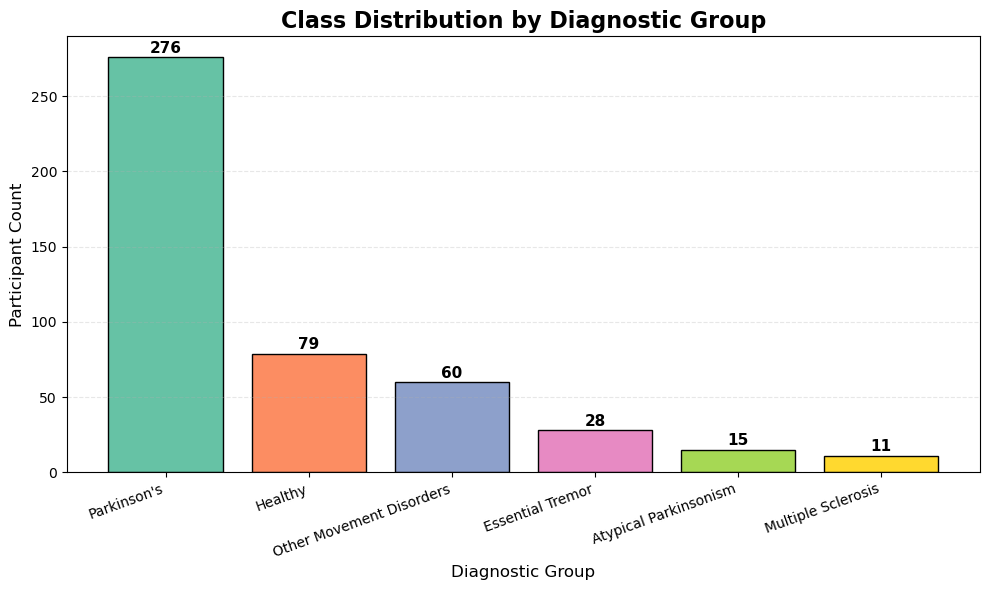

In [223]:
# Create class distribution bar chart
plt.figure(figsize=(10,6))

colors = plt.cm.Set2.colors

bars = plt.bar(
    participant_counts["Diagnostic Group"],
    participant_counts["Participant Count"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

# Add participant count labels above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        f"{int(height)}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Customize chart title
plt.title(
    "Class Distribution by Diagnostic Group",
    fontsize=16,
    fontweight="bold"
)

# Label x-axis
plt.xlabel(
    "Diagnostic Group",
    fontsize=12
)

# Label y-axis
plt.ylabel(
    "Participant Count",
    fontsize=12
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=20, ha="right")

# Add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the chart
plt.show()